# 🏠 Dự Đoán Giá Bất Động Sản bằng Mạng Neural Nhân Tạo (ANN)

**Framework:** PyTorch (tương thích Python 3.9 → 3.14+)  
**Tập dữ liệu:** King County House Sales (`kc_house_data.csv`)  
**Mục tiêu:** Dự đoán cột `price` (giá bán ngôi nhà)

---
## 📋 Quy Trình
1. Cài đặt & Import thư viện
2. Tiền xử lý dữ liệu
3. Xây dựng mô hình ANN
4. Huấn luyện mô hình
5. Đánh giá & Trực quan hóa

---
## 📦 Bước 0 — Cài Đặt Thư Viện
> **Chạy cell này 1 lần duy nhất.** PyTorch hỗ trợ Python 3.9–3.14+, không như TensorFlow.

In [1]:
# ================================================================
# CÀI ĐẶT THƯ VIỆN — Chỉ cài những gói còn thiếu
# ================================================================
import sys, subprocess

def pip_install(package, import_name=None):
    """Cài đặt package nếu chưa có, bỏ qua nếu đã có."""
    import_name = import_name or package
    try:
        __import__(import_name)
        print(f'  ✅ {package:20s} — đã có sẵn')
    except ImportError:
        print(f'  📥 {package:20s} — đang cài đặt...', end=' ', flush=True)
        result = subprocess.run(
            [sys.executable, '-m', 'pip', 'install', package, '-q', '--no-warn-script-location'],
            capture_output=True, text=True
        )
        if result.returncode == 0:
            print('✅ xong!')
        else:
            print(f'❌ THẤT BẠI!\n  Lỗi: {result.stderr.strip()[:200]}')

print('🔧 Kiểm tra & cài đặt thư viện...')
print('=' * 50)
pip_install('numpy')
pip_install('pandas')
pip_install('matplotlib')
pip_install('seaborn')
pip_install('scikit-learn',  'sklearn')
pip_install('scipy')
# PyTorch CPU — nhẹ hơn, không cần GPU, hỗ trợ Python 3.14
pip_install('torch')
print('=' * 50)
print('🎉 Hoàn tất! Hãy tiếp tục chạy các cell bên dưới.')

🔧 Kiểm tra & cài đặt thư viện...
  ✅ numpy                — đã có sẵn
  ✅ pandas               — đã có sẵn
  ✅ matplotlib           — đã có sẵn
  ✅ seaborn              — đã có sẵn
  ✅ scikit-learn         — đã có sẵn
  ✅ scipy                — đã có sẵn
  ✅ torch                — đã có sẵn
🎉 Hoàn tất! Hãy tiếp tục chạy các cell bên dưới.


---
## 📚 Bước 1 — Import Thư Viện

In [2]:
# ================================================================
# IMPORT TẤT CẢ THƯ VIỆN CẦN DÙNG
# ================================================================

# --- Xử lý dữ liệu ---
import numpy as np
import pandas as pd

# --- Trực quan hóa ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import norm

# --- Machine Learning (Scikit-learn) ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# --- Deep Learning (PyTorch) ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# --- Cài đặt hiển thị ---
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# --- Seed để tái lập kết quả ---
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# --- Thiết bị tính toán: GPU nếu có, ngược lại dùng CPU ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('✅ Import thư viện thành công!')
print(f'   PyTorch version : {torch.__version__}')
print(f'   NumPy version   : {np.__version__}')
print(f'   Pandas version  : {pd.__version__}')
print(f'   Thiết bị dùng   : {DEVICE}')

✅ Import thư viện thành công!
   PyTorch version : 2.9.0+cu126
   NumPy version   : 2.3.5
   Pandas version  : 2.3.3
   Thiết bị dùng   : cuda


---
## 🗂️ Bước 2 — Tiền Xử Lý Dữ Liệu (Data Preprocessing)

### 2.1 Đọc và Khám Phá Dữ Liệu

In [3]:
# ================================================================
# ĐỌC FILE CSV VÀ KHÁM PHÁ DỮ LIỆU
# ================================================================

df = pd.read_csv('kc_house_data.csv')

print('=' * 55)
print('📊 TỔNG QUAN TẬP DỮ LIỆU')
print('=' * 55)
print(f'  Số dòng (mẫu)      : {df.shape[0]:,}')
print(f'  Số cột (đặc trưng) : {df.shape[1]}')
print()
df.head()

📊 TỔNG QUAN TẬP DỮ LIỆU
  Số dòng (mẫu)      : 21,613
  Số cột (đặc trưng) : 18



,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,price
0,3,1.00,1180,5650,1.00,0,0,3,7,1180,0,1955,0,47.51,-122.26,1340,5650,221900.00
1,3,2.25,2570,7242,2.00,0,0,3,7,2170,400,1951,1991,47.72,-122.32,1690,7639,538000.00
2,2,1.00,770,10000,1.00,0,0,3,6,770,0,1933,0,47.74,-122.23,2720,8062,180000.00
3,4,3.00,1960,5000,1.00,0,0,5,7,1050,910,1965,0,47.52,-122.39,1360,5000,604000.00
4,3,2.00,1680,8080,1.00,0,0,3,8,1680,0,1987,0,47.62,-122.05,1800,7503,510000.00


In [4]:
# Thống kê mô tả
print('📈 Thống kê mô tả:')
df.describe()

📈 Thống kê mô tả:


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15,price
count,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00,21613.00
mean,3.37,2.11,2079.90,15106.97,1.49,0.01,0.23,3.41,7.66,1788.39,291.51,1971.01,84.40,47.56,-122.21,1986.55,12768.46,540182.16
std,0.93,0.77,918.44,41420.51,0.54,0.09,0.77,0.65,1.18,828.09,442.58,29.37,401.68,0.14,0.14,685.39,27304.18,367362.23
min,0.00,0.00,290.00,520.00,1.00,0.00,0.00,1.00,1.00,290.00,0.00,1900.00,0.00,47.16,-122.52,399.00,651.00,75000.00
25%,3.00,1.75,1427.00,5040.00,1.00,0.00,0.00,3.00,7.00,1190.00,0.00,1951.00,0.00,47.47,-122.33,1490.00,5100.00,321950.00
50%,3.00,2.25,1910.00,7618.00,1.50,0.00,0.00,3.00,7.00,1560.00,0.00,1975.00,0.00,47.57,-122.23,1840.00,7620.00,450000.00
75%,4.00,2.50,2550.00,10688.00,2.00,0.00,0.00,4.00,8.00,2210.00,560.00,1997.00,0.00,47.68,-122.12,2360.00,10083.00,645000.00
max,33.00,8.00,13540.00,1651359.00,3.50,1.00,4.00,5.00,13.00,9410.00,4820.00,2015.00,2015.00,47.78,-121.31,6210.00,871200.00,7700000.00


### 2.2 Xử Lý Dữ Liệu Khuyết Thiếu (Missing Values)

In [5]:
# ================================================================
# KIỂM TRA VÀ XỬ LÝ MISSING VALUES
# ================================================================

print('🔍 Kiểm tra giá trị khuyết thiếu:')
print('=' * 45)

missing = df.isnull().sum()
missing_pct = missing / len(df) * 100
missing_df = pd.DataFrame({'Số lượng': missing, 'Tỷ lệ (%)': missing_pct})
has_missing = missing_df[missing_df['Số lượng'] > 0]

if has_missing.empty:
    print('  ✅ Không có dữ liệu khuyết thiếu!')
else:
    print(has_missing)
    df = df.dropna()  # Xóa các dòng có giá trị thiếu
    print(f'  ✅ Đã xóa. Còn lại: {len(df):,} dòng.')

print(f'  Kích thước cuối : {df.shape}')

🔍 Kiểm tra giá trị khuyết thiếu:
  ✅ Không có dữ liệu khuyết thiếu!
  Kích thước cuối : (21613, 18)


### 2.3 Phân Tách X và y

In [6]:
# ================================================================
# TÁCH BIẾN ĐỘC LẬP (X) VÀ BIẾN PHỤ THUỘC (y = price)
# ================================================================

# Loại bỏ các cột không mang giá trị dự báo trực tiếp
DROP_COLS = [c for c in ['id', 'date', 'price'] if c in df.columns]

y = df['price'].values.astype(np.float32)   # Target: giá nhà
X_df = df.drop(columns=DROP_COLS, errors='ignore')
feature_names = X_df.columns.tolist()
X = X_df.values.astype(np.float32)          # Features

print('📌 Phân tách dữ liệu:')
print('=' * 45)
print(f'  Số đặc trưng  : {X.shape[1]}')
print(f'  Số mẫu        : {X.shape[0]:,}')
print(f'  Shape X       : {X.shape}')
print(f'  Shape y       : {y.shape}')
print()
print('Danh sách đặc trưng:')
for i, name in enumerate(feature_names, 1):
    print(f'  {i:2d}. {name}')

📌 Phân tách dữ liệu:
  Số đặc trưng  : 17
  Số mẫu        : 21,613
  Shape X       : (21613, 17)
  Shape y       : (21613,)

Danh sách đặc trưng:
   1. bedrooms
   2. bathrooms
   3. sqft_living
   4. sqft_lot
   5. floors
   6. waterfront
   7. view
   8. condition
   9. grade
  10. sqft_above
  11. sqft_basement
  12. yr_built
  13. yr_renovated
  14. lat
  15. long
  16. sqft_living15
  17. sqft_lot15


### 2.4 Chia Train/Test (80:20) và Chuẩn Hóa (StandardScaler)

In [7]:
# ================================================================
# CHIA TRAIN / TEST VÀ CHUẨN HÓA DỮ LIỆU
# ================================================================

# --- Chia tập 80% Train / 20% Test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

print('✂️  Kết quả chia tập:')
print(f'  Train : {X_train.shape[0]:,} mẫu')
print(f'  Test  : {X_test.shape[0]:,} mẫu')

# --- Chuẩn hóa bằng StandardScaler ---
# Quan trọng với ANN vì lat/long (~47) và sqft (~2000) có thang đo khác nhau.
# CHỈ fit() trên Train, rồi transform() cả hai — tránh data leakage!
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)   # fit + transform Train
X_test_s  = scaler_X.transform(X_test)        # chỉ transform Test

# Chuẩn hóa cả y (giá nhà) — giúp mạng học nhanh hơn, tránh gradient bùng nổ
# Sẽ inverse_transform lại khi đánh giá
scaler_y = StandardScaler()
y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_s  = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

print(f'\n  X_train_scaled — Mean: {X_train_s.mean():.4f}, Std: {X_train_s.std():.4f}')
print(f'  y_train_scaled — Mean: {y_train_s.mean():.4f}, Std: {y_train_s.std():.4f}')
print('  ✅ Chuẩn hóa hoàn tất!')

# --- Chuyển sang PyTorch Tensor ---
# PyTorch yêu cầu dữ liệu ở dạng Tensor thay vì numpy array
X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train_s, dtype=torch.float32).unsqueeze(1)  # (N,) → (N,1)
X_test_t  = torch.tensor(X_test_s,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test_s,  dtype=torch.float32).unsqueeze(1)

# --- Tạo DataLoader để chia batch khi huấn luyện ---
BATCH_SIZE = 64
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f'\n  Batch size    : {BATCH_SIZE}')
print(f'  Số batch/epoch: {len(train_loader)}')

✂️  Kết quả chia tập:
  Train : 17,290 mẫu
  Test  : 4,323 mẫu

  X_train_scaled — Mean: 0.0000, Std: 1.0000
  y_train_scaled — Mean: -0.0000, Std: 1.0000
  ✅ Chuẩn hóa hoàn tất!

  Batch size    : 64
  Số batch/epoch: 271


---
## 🧠 Bước 3 — Xây Dựng Mô Hình ANN (PyTorch)

In [8]:
# ================================================================
# ĐỊNH NGHĨA KIẾN TRÚC MẠNG ANN BẰNG PYTORCH
# ================================================================
#
# Kiến trúc (Feedforward Neural Network):
#
#   Input (17)  →  Linear(256) → BatchNorm → ReLU → Dropout(0.30)
#               →  Linear(128) → BatchNorm → ReLU → Dropout(0.20)
#               →  Linear(64)  → BatchNorm → ReLU → Dropout(0.10)
#               →  Linear(32)  → ReLU
#               →  Linear(1)   → Output (giá trị liên tục)
#
# Giải thích lựa chọn:
#   BatchNorm : Chuẩn hóa nội bộ → huấn luyện ổn định, nhanh hội tụ hơn
#   ReLU      : Hàm kích hoạt đơn giản, tránh vanishing gradient
#   Dropout   : Ngẫu nhiên tắt nơ-ron khi train → giảm overfitting
#   Output=1  : Bài toán hồi quy → 1 đầu ra, không dùng sigmoid/softmax
# ================================================================

class HousePriceANN(nn.Module):
    """Mạng ANN hồi quy dự đoán giá nhà."""

    def __init__(self, n_features: int):
        super(HousePriceANN, self).__init__()

        # Định nghĩa kiến trúc mạng bằng nn.Sequential
        self.network = nn.Sequential(

            # ---- Tầng ẩn 1: 256 nơ-ron ----
            nn.Linear(n_features, 256),  # Fully connected layer
            nn.BatchNorm1d(256),          # Chuẩn hóa batch
            nn.ReLU(),                    # Hàm kích hoạt phi tuyến
            nn.Dropout(p=0.30),           # Dropout 30%

            # ---- Tầng ẩn 2: 128 nơ-ron ----
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.20),           # Dropout 20% (giảm dần)

            # ---- Tầng ẩn 3: 64 nơ-ron ----
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=0.10),           # Dropout 10%

            # ---- Tầng ẩn 4: 32 nơ-ron (tinh chỉnh) ----
            nn.Linear(64, 32),
            nn.ReLU(),

            # ---- Tầng đầu ra: 1 nơ-ron (hồi quy) ----
            # Không dùng hàm kích hoạt → đầu ra là giá trị thực bất kỳ
            nn.Linear(32, 1)
        )

    def forward(self, x):
        """Lan truyền thuận (Forward Pass)."""
        return self.network(x)


# ---- Khởi tạo mô hình ----
n_features = X_train_t.shape[1]
model = HousePriceANN(n_features).to(DEVICE)

# ---- In tóm tắt kiến trúc ----
print('🧠 Kiến trúc mô hình ANN (PyTorch):')
print('=' * 55)
print(model)
print()

# Đếm tổng số tham số có thể huấn luyện
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'  Tổng số tham số : {total_params:,}')
print(f'  Thiết bị        : {DEVICE}')

🧠 Kiến trúc mô hình ANN (PyTorch):
HousePriceANN(
  (network): Sequential(
    (0): Linear(in_features=17, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): ReLU()
    (14): Linear(in_features=32, out_features=1, bias=True)
  )
)

  Tổng số tham số : 48,769
  Thiết bị        : cuda


---
## 🏋️ Bước 4 — Huấn Luyện Mô Hình (Model Training)

In [9]:
# ================================================================
# THIẾT LẬP OPTIMIZER, LOSS FUNCTION VÀ VÒNG LẶP HUẤN LUYỆN
# ================================================================

# --- Loss function: MSE (Mean Squared Error) ---
# Chuẩn cho bài toán hồi quy: phạt nặng sai số lớn
criterion = nn.MSELoss()

# --- Optimizer: Adam ---
# Kết hợp ưu điểm của RMSprop + Momentum, tự điều chỉnh learning rate
LEARNING_RATE = 0.001
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
# weight_decay=1e-5 → L2 regularization nhẹ, thêm một lớp chống overfitting

# --- Scheduler: ReduceLROnPlateau ---
# Tự động giảm learning rate khi val_loss không cải thiện
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
)

# ----------------------------------------------------------------
# VÒNG LẶP HUẤN LUYỆN (TRAINING LOOP)
# ----------------------------------------------------------------
EPOCHS        = 300   # Số epoch tối đa
PATIENCE      = 20    # EarlyStopping: dừng sau n epoch không cải thiện
VAL_RATIO     = 0.15  # 15% của Train dùng làm Validation

# Tách Validation từ Train
val_size  = int(len(X_train_t) * VAL_RATIO)
train_size = len(X_train_t) - val_size
X_tr, X_val = X_train_t[:train_size], X_train_t[train_size:]
y_tr, y_val = y_train_t[:train_size], y_train_t[train_size:]

# DataLoader cho sub-train
tr_dataset   = TensorDataset(X_tr, y_tr)
tr_loader    = DataLoader(tr_dataset, batch_size=BATCH_SIZE, shuffle=True)

# --- Lưu lịch sử loss ---
train_losses, val_losses = [], []
train_maes,   val_maes   = [], []

# --- Biến theo dõi EarlyStopping ---
best_val_loss    = float('inf')
best_model_state = None
patience_counter = 0

print('🚀 Bắt đầu huấn luyện...')
print(f'   Epochs tối đa   : {EPOCHS}')
print(f'   Batch size       : {BATCH_SIZE}')
print(f'   Validation size  : {val_size:,} mẫu ({VAL_RATIO:.0%} từ Train)')
print(f'   EarlyStopping    : patience={PATIENCE}')
print('=' * 60)

for epoch in range(1, EPOCHS + 1):

    # ---- TRAIN PHASE ----
    model.train()          # Bật BatchNorm + Dropout
    batch_losses, batch_maes = [], []

    for X_batch, y_batch in tr_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()          # Xóa gradient cũ
        y_hat = model(X_batch)         # Forward pass
        loss  = criterion(y_hat, y_batch)  # Tính MSE loss
        loss.backward()                # Backpropagation
        optimizer.step()               # Cập nhật trọng số

        batch_losses.append(loss.item())
        batch_maes.append(torch.mean(torch.abs(y_hat - y_batch)).item())

    train_loss = np.mean(batch_losses)
    train_mae  = np.mean(batch_maes)

    # ---- VALIDATION PHASE ----
    model.eval()           # Tắt Dropout, BatchNorm dùng running stats
    with torch.no_grad():  # Không tính gradient khi validate
        X_val_d = X_val.to(DEVICE)
        y_val_d = y_val.to(DEVICE)
        y_val_hat = model(X_val_d)
        val_loss  = criterion(y_val_hat, y_val_d).item()
        val_mae   = torch.mean(torch.abs(y_val_hat - y_val_d)).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_maes.append(train_mae)
    val_maes.append(val_mae)

    # Giảm learning rate nếu val_loss không giảm
    scheduler.step(val_loss)

    # ---- EARLYSTOPPING ----
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_model_state = model.state_dict().copy()  # Lưu trọng số tốt nhất
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'  ⏹  EarlyStopping tại epoch {epoch} (val_loss không giảm sau {PATIENCE} epoch)')
            break

    # In log mỗi 10 epoch
    if epoch % 10 == 0 or epoch == 1:
        current_lr = optimizer.param_groups[0]['lr']
        print(f'  Epoch [{epoch:3d}/{EPOCHS}] '
              f'| Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} '
              f'| Train MAE: {train_mae:.4f} | Val MAE: {val_mae:.4f} '
              f'| LR: {current_lr:.6f}')

# Khôi phục trọng số tốt nhất (best checkpoint)
model.load_state_dict(best_model_state)

print(f'\n✅ Huấn luyện hoàn tất! Số epoch thực chạy: {len(train_losses)}')
print(f'   Best val_loss: {best_val_loss:.6f}')

🚀 Bắt đầu huấn luyện...
   Epochs tối đa   : 300
   Batch size       : 64
   Validation size  : 2,593 mẫu (15% từ Train)
   EarlyStopping    : patience=20
  Epoch [  1/300] | Train Loss: 0.3680 | Val Loss: 0.1731 | Train MAE: 0.3497 | Val MAE: 0.2507 | LR: 0.001000
  Epoch [ 10/300] | Train Loss: 0.1825 | Val Loss: 0.1308 | Train MAE: 0.2556 | Val MAE: 0.2192 | LR: 0.001000
  Epoch [ 20/300] | Train Loss: 0.1629 | Val Loss: 0.1120 | Train MAE: 0.2462 | Val MAE: 0.2057 | LR: 0.001000
  Epoch [ 30/300] | Train Loss: 0.1593 | Val Loss: 0.1188 | Train MAE: 0.2424 | Val MAE: 0.2123 | LR: 0.000500
  Epoch [ 40/300] | Train Loss: 0.1257 | Val Loss: 0.1091 | Train MAE: 0.2268 | Val MAE: 0.2037 | LR: 0.000500
  Epoch [ 50/300] | Train Loss: 0.1247 | Val Loss: 0.1089 | Train MAE: 0.2233 | Val MAE: 0.1974 | LR: 0.000500
  Epoch [ 60/300] | Train Loss: 0.1134 | Val Loss: 0.1058 | Train MAE: 0.2192 | Val MAE: 0.1971 | LR: 0.000250
  ⏹  EarlyStopping tại epoch 67 (val_loss không giảm sau 20 epoch)



---
## 📊 Bước 5 — Đánh Giá Mô Hình (Model Evaluation)

### 5.1 Tính Chỉ Số Đánh Giá

In [10]:
# ================================================================
# DỰ ĐOÁN TRÊN TẬP TEST VÀ TÍNH CÁC CHỈ SỐ ĐÁNH GIÁ
# ================================================================

model.eval()  # Chuyển sang chế độ đánh giá
with torch.no_grad():
    y_pred_s = model(X_test_t.to(DEVICE)).cpu().numpy().flatten()

# Inverse transform: chuyển lại từ giá trị chuẩn hóa → USD thực
y_pred = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).flatten()
# y_test đã là USD gốc (chưa chuẩn hóa) → dùng trực tiếp

# ---- Tính các chỉ số ----
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print('🏆 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST')
print('=' * 55)
print(f'  📌 R² Score : {r2:.4f}')
print(f'     → Mô hình giải thích {r2*100:.2f}% phương sai dữ liệu')
print()
print(f'  📌 RMSE     : ${rmse:,.0f}')
print(f'     → Trung bình sai số ± ${rmse:,.0f}')
print()
print(f'  📌 MAE      : ${mae:,.0f}')
print(f'     → Sai số tuyệt đối trung bình ± ${mae:,.0f}')
print()
print(f'  📌 MAPE     : {mape:.2f}%')
print(f'     → Trung bình lệch {mape:.2f}% so với giá thực')
print('=' * 55)

# Nhận xét tự động
if r2 >= 0.90:
    rating = '✅ RẤT TỐT'
elif r2 >= 0.80:
    rating = '✅ TỐT'
elif r2 >= 0.70:
    rating = '⚠️  CHẤP NHẬN ĐƯỢC'
else:
    rating = '❌ CẦN CẢI THIỆN'
print(f'  Đánh giá: {rating} (R² = {r2:.4f})')

🏆 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST
  📌 R² Score : 0.8816
     → Mô hình giải thích 88.16% phương sai dữ liệu

  📌 RMSE     : $133,884
     → Trung bình sai số ± $133,884

  📌 MAE      : $75,321
     → Sai số tuyệt đối trung bình ± $75,321

  📌 MAPE     : 14.62%
     → Trung bình lệch 14.62% so với giá thực
  Đánh giá: ✅ TỐT (R² = 0.8816)


### 5.2 Đồ Thị Lịch Sử Huấn Luyện (Loss & MAE)

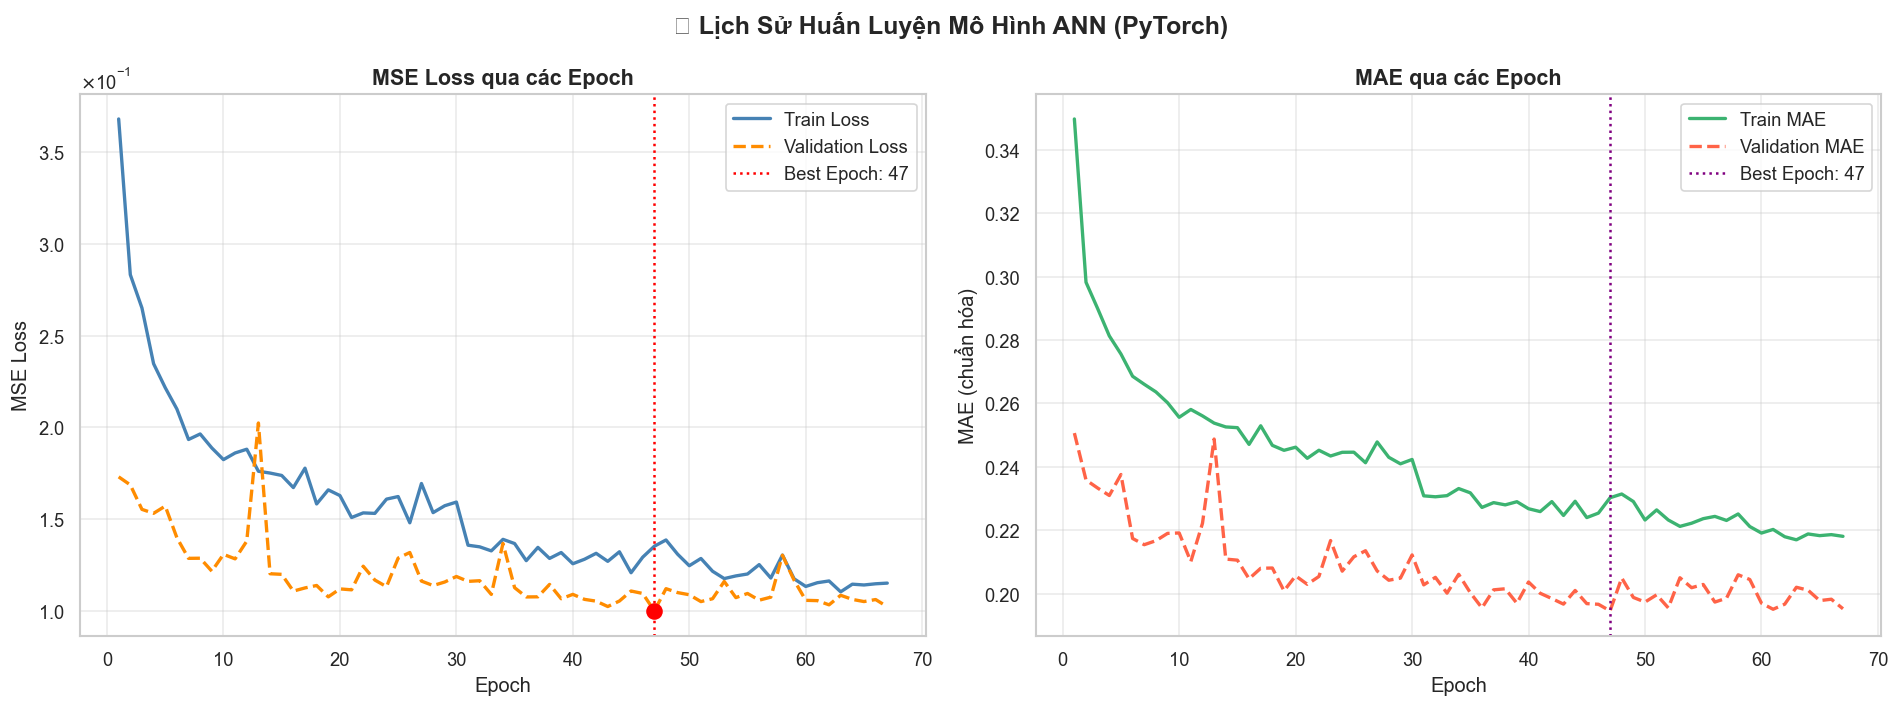

  Đã lưu: training_history.png
  Best epoch (val_loss thấp nhất): 47


In [11]:
# ================================================================
# VẼ LỊCH SỬ HUẤN LUYỆN: LOSS VÀ MAE QUA CÁC EPOCH
# ================================================================

epochs_range = range(1, len(train_losses) + 1)
best_epoch   = np.argmin(val_losses) + 1

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('📈 Lịch Sử Huấn Luyện Mô Hình ANN (PyTorch)',
             fontsize=15, fontweight='bold')

# ---- Đồ thị 1: MSE Loss ----
ax1 = axes[0]
ax1.plot(epochs_range, train_losses, label='Train Loss',
         color='steelblue', linewidth=2)
ax1.plot(epochs_range, val_losses,   label='Validation Loss',
         color='darkorange', linewidth=2, linestyle='--')
ax1.axvline(x=best_epoch, color='red', linestyle=':', linewidth=1.5,
            label=f'Best Epoch: {best_epoch}')
ax1.scatter(best_epoch, val_losses[best_epoch-1], color='red', s=80, zorder=5)
ax1.set_title('MSE Loss qua các Epoch', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE Loss')
ax1.legend(); ax1.grid(True, alpha=0.4)
ax1.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax1.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

# ---- Đồ thị 2: MAE ----
ax2 = axes[1]
ax2.plot(epochs_range, train_maes, label='Train MAE',
         color='mediumseagreen', linewidth=2)
ax2.plot(epochs_range, val_maes,   label='Validation MAE',
         color='tomato', linewidth=2, linestyle='--')
best_mae_epoch = np.argmin(val_maes) + 1
ax2.axvline(x=best_mae_epoch, color='purple', linestyle=':', linewidth=1.5,
            label=f'Best Epoch: {best_mae_epoch}')
ax2.set_title('MAE qua các Epoch', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('MAE (chuẩn hóa)')
ax2.legend(); ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'  Đã lưu: training_history.png')
print(f'  Best epoch (val_loss thấp nhất): {best_epoch}')

### 5.3 Đồ Thị So Sánh Thực Tế vs Dự Đoán

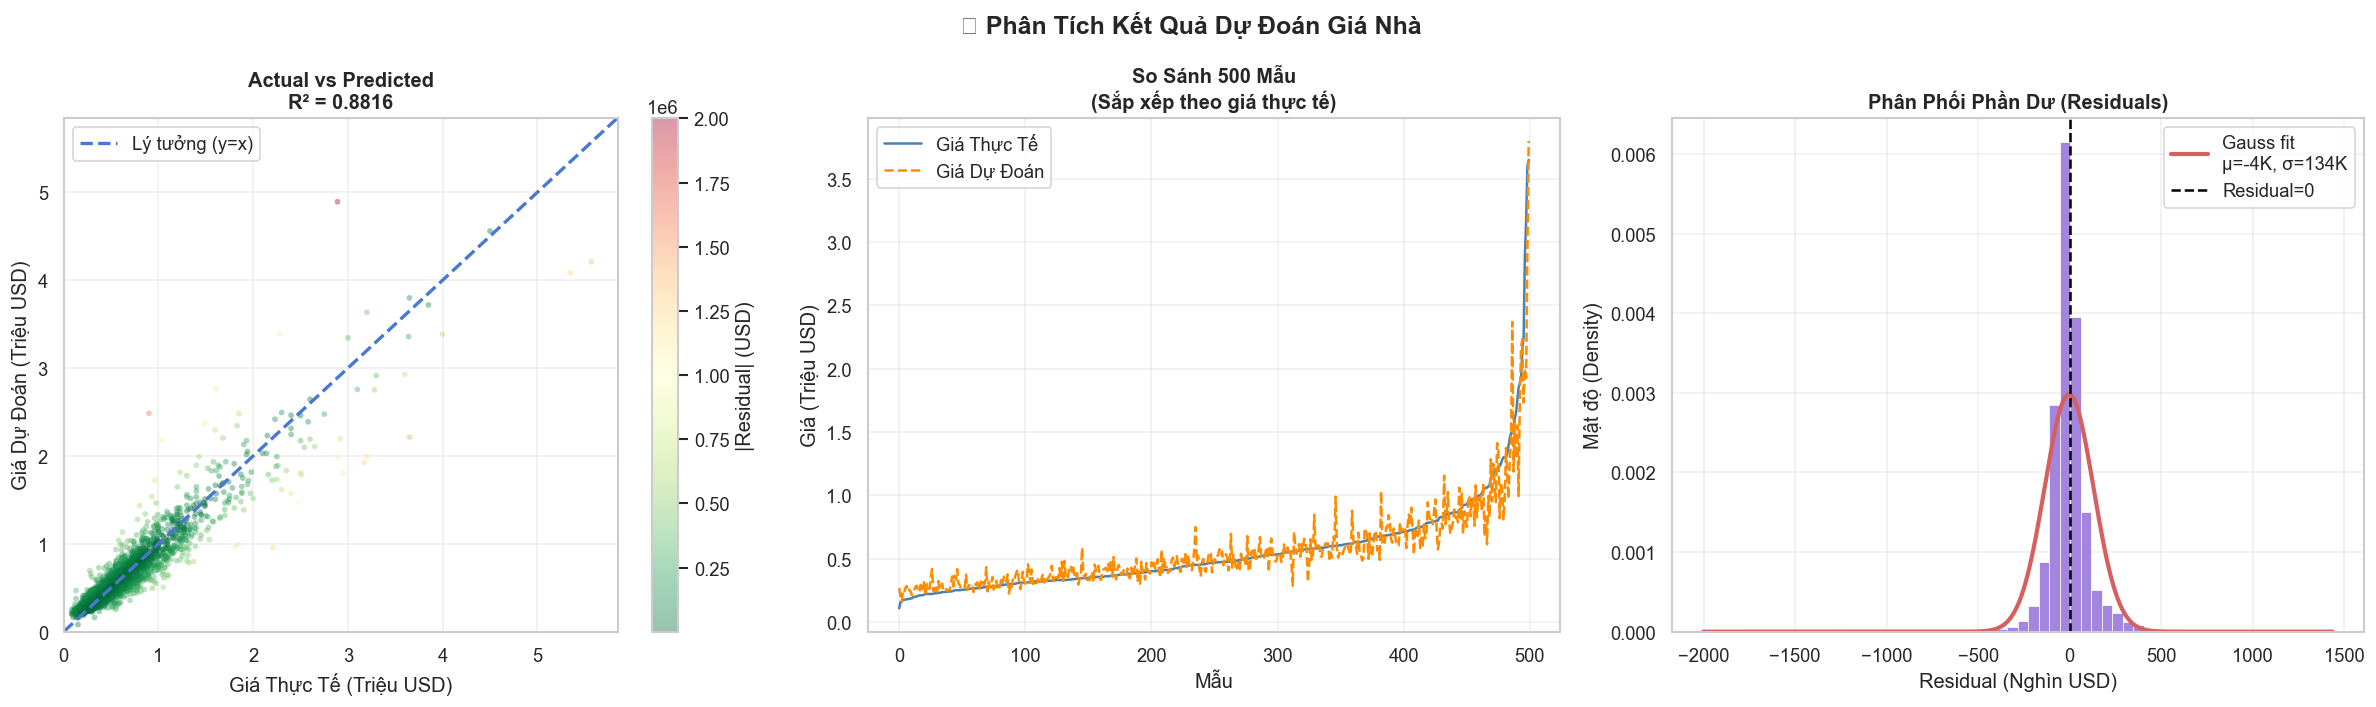

  Đã lưu: prediction_analysis.png


In [12]:
# ================================================================
# VẼ ĐỒ THỊ PHÂN TÍCH KẾT QUẢ DỰ ĐOÁN
# ================================================================

residuals  = y_test - y_pred          # Phần dư (Residuals)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('🏠 Phân Tích Kết Quả Dự Đoán Giá Nhà',
             fontsize=15, fontweight='bold')

# ---- Đồ thị 1: Scatter — Actual vs Predicted ----
ax1 = axes[0]
sc = ax1.scatter(y_test/1e6, y_pred/1e6, alpha=0.4, s=12,
                 c=np.abs(residuals), cmap='RdYlGn_r', edgecolors='none')
plt.colorbar(sc, ax=ax1, label='|Residual| (USD)')
lim = [0, max(y_test.max(), y_pred.max()) / 1e6 * 1.05]
ax1.plot(lim, lim, 'b--', linewidth=2, label='Lý tưởng (y=x)')
ax1.set_title(f'Actual vs Predicted\nR² = {r2:.4f}', fontsize=12, fontweight='bold')
ax1.set_xlabel('Giá Thực Tế (Triệu USD)')
ax1.set_ylabel('Giá Dự Đoán (Triệu USD)')
ax1.legend(); ax1.set_xlim(lim); ax1.set_ylim(lim)
ax1.grid(True, alpha=0.3)

# ---- Đồ thị 2: Line — So sánh 500 mẫu ----
ax2 = axes[1]
n_show   = 500
sort_idx = np.argsort(y_test[:n_show])
ax2.plot(range(n_show), y_test[sort_idx]/1e6,
         label='Giá Thực Tế', color='steelblue', linewidth=1.5)
ax2.plot(range(n_show), y_pred[sort_idx]/1e6,
         label='Giá Dự Đoán', color='darkorange', linewidth=1.5, linestyle='--')
ax2.set_title(f'So Sánh {n_show} Mẫu\n(Sắp xếp theo giá thực tế)',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Mẫu'); ax2.set_ylabel('Giá (Triệu USD)')
ax2.legend(); ax2.grid(True, alpha=0.3)

# ---- Đồ thị 3: Histogram — Phân phối phần dư ----
ax3 = axes[2]
res_K = residuals / 1_000
ax3.hist(res_K, bins=60, color='mediumpurple', edgecolor='white',
         linewidth=0.5, alpha=0.85, density=True)
mu, std = norm.fit(res_K)
x_r = np.linspace(res_K.min(), res_K.max(), 300)
ax3.plot(x_r, norm.pdf(x_r, mu, std), 'r-', linewidth=2.5,
         label=f'Gauss fit\nμ={mu:.0f}K, σ={std:.0f}K')
ax3.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Residual=0')
ax3.set_title('Phân Phối Phần Dư (Residuals)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Residual (Nghìn USD)')
ax3.set_ylabel('Mật độ (Density)')
ax3.legend(); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Đã lưu: prediction_analysis.png')

### 5.4 Tầm Quan Trọng Đặc Trưng (Feature Importance)

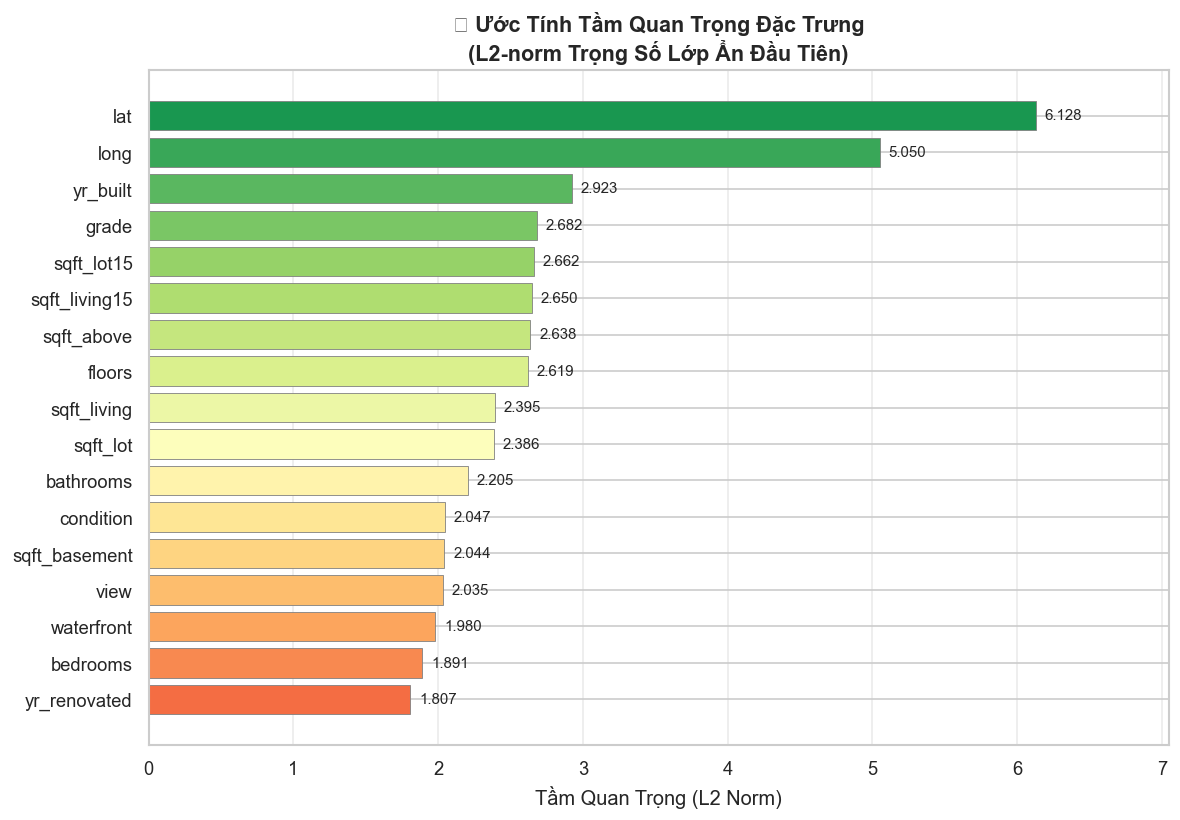

Top 5 đặc trưng quan trọng nhất:
  1. lat                 : 6.1281
  2. long                : 5.0497
  3. yr_built            : 2.9234
  4. grade               : 2.6820
  5. sqft_lot15          : 2.6620


In [13]:
# ================================================================
# ƯỚC TÍNH TẦM QUAN TRỌNG ĐẶC TRƯNG
# (L2-norm trọng số của lớp đầu tiên)
# ================================================================

# Lấy ma trận trọng số lớp Linear đầu tiên
# Hình dạng: (256, n_features) → transpose → (n_features, 256)
first_layer = model.network[0]  # nn.Linear(n_features, 256)
weights = first_layer.weight.data.cpu().numpy()  # (256, 17)
feature_importance = np.linalg.norm(weights, axis=0)  # (17,) — chuẩn theo cột

fi_df = pd.DataFrame({
    'Đặc trưng': feature_names,
    'Tầm quan trọng': feature_importance
}).sort_values('Tầm quan trọng', ascending=True)

# ---- Vẽ biểu đồ ----
fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(fi_df)))
bars = ax.barh(fi_df['Đặc trưng'], fi_df['Tầm quan trọng'],
               color=colors, edgecolor='gray', linewidth=0.5)
for bar, val in zip(bars, fi_df['Tầm quan trọng']):
    ax.text(bar.get_width() + fi_df['Tầm quan trọng'].max()*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha='left', fontsize=9)

ax.set_title('🔍 Ước Tính Tầm Quan Trọng Đặc Trưng\n'
             '(L2-norm Trọng Số Lớp Ẩn Đầu Tiên)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Tầm Quan Trọng (L2 Norm)')
ax.grid(True, axis='x', alpha=0.4)
ax.set_xlim(0, fi_df['Tầm quan trọng'].max() * 1.15)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 đặc trưng quan trọng nhất:')
for i, (_, row) in enumerate(fi_df.tail(5).iloc[::-1].iterrows(), 1):
    print(f'  {i}. {row["Đặc trưng"]:20s}: {row["Tầm quan trọng"]:.4f}')

---
## 📋 Bước 6 — Tổng Kết & Lưu Mô Hình

In [14]:
# ================================================================
# TỔNG KẾT KẾT QUẢ VÀ LƯU MÔ HÌNH
# ================================================================

print('═' * 60)
print('  📋 BÁO CÁO TỔNG KẾT — ANN DỰ ĐOÁN GIÁ NHÀ (PyTorch)')
print('═' * 60)
print(f'\n  Dữ liệu       : King County House Sales')
print(f'  Tổng mẫu      : {len(df):,}  |  Đặc trưng: {n_features}')
print(f'  Train/Test    : 80% / 20%')
print(f'\n  Kiến trúc     : Input({n_features}) → 256 → 128 → 64 → 32 → 1')
print(f'  Tham số       : {sum(p.numel() for p in model.parameters()):,}')
print(f'  Kỹ thuật      : BatchNorm + Dropout + L2 Regularization')
print(f'\n  Optimizer     : Adam (lr=0.001, weight_decay=1e-5)')
print(f'  Loss          : MSE  |  Scheduler: ReduceLROnPlateau')
print(f'  Epochs chạy   : {len(train_losses)}/{EPOCHS}  (EarlyStopping)')
print(f'\n  R² Score      : {r2:.4f}  ({r2*100:.2f}% phương sai)')
print(f'  RMSE          : ${rmse:,.0f}')
print(f'  MAE           : ${mae:,.0f}')
print(f'  MAPE          : {mape:.2f}%')

# Lưu mô hình PyTorch
torch.save({
    'model_state_dict' : model.state_dict(),
    'scaler_X_mean'    : scaler_X.mean_,
    'scaler_X_scale'   : scaler_X.scale_,
    'scaler_y_mean'    : scaler_y.mean_,
    'scaler_y_scale'   : scaler_y.scale_,
    'feature_names'    : feature_names,
    'metrics'          : {'r2': r2, 'rmse': rmse, 'mae': mae, 'mape': mape}
}, 'ann_house_price_model.pt')

print(f'\n  Mô hình đã lưu: ann_house_price_model.pt')
print('═' * 60)
print('  ✅ HOÀN THÀNH!')
print('═' * 60)

════════════════════════════════════════════════════════════
  📋 BÁO CÁO TỔNG KẾT — ANN DỰ ĐOÁN GIÁ NHÀ (PyTorch)
════════════════════════════════════════════════════════════

  Dữ liệu       : King County House Sales
  Tổng mẫu      : 21,613  |  Đặc trưng: 17
  Train/Test    : 80% / 20%

  Kiến trúc     : Input(17) → 256 → 128 → 64 → 32 → 1
  Tham số       : 48,769
  Kỹ thuật      : BatchNorm + Dropout + L2 Regularization

  Optimizer     : Adam (lr=0.001, weight_decay=1e-5)
  Loss          : MSE  |  Scheduler: ReduceLROnPlateau
  Epochs chạy   : 67/300  (EarlyStopping)

  R² Score      : 0.8816  (88.16% phương sai)
  RMSE          : $133,884
  MAE           : $75,321
  MAPE          : 14.62%

  Mô hình đã lưu: ann_house_price_model.pt
════════════════════════════════════════════════════════════
  ✅ HOÀN THÀNH!
════════════════════════════════════════════════════════════
